# Cenário 5: Avaliação de Risco e Segurança Pública (Criminologia / Justiça)

Seminário de Viés (P1). Enunciado: Sub representar intencionalmente um grupo étnico/racial no conjunto de treinamento 
para induzir taxas de erro díspares entre os grupos

Dados: COMPAS (ProPublica, Broward County). O modelo prevê `two_year_recid`, ou seja, se a pessoa foi presa de novo em até dois anos. Comparamos afro-americanos e caucasianos, porque os outros grupos são pequenos. Um dos grupos fica com 10% dos dados, só no treino. O teste não é alterado.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

pd.set_option("display.precision", 3) # Numero de casas decimais
pd.set_option("display.width", 140)

TARGET = "two_year_recid"
NUMERIC = ["age", "priors_count", "juv_fel_count", "juv_misd_count", "juv_other_count"]
CATEGORICAL = ["sex", "c_charge_degree"]

GROUP_SUB = "African-American"
GROUP_REF = "Caucasian"
GROUPS = [GROUP_SUB, GROUP_REF]
FRAC = 0.10
N_SEEDS = 30

In [2]:
def rates(y, pred):
    tn, fp, fn, tp = confusion_matrix(y, pred, labels=[0, 1]).ravel()
    pos, neg = tp + fn, fp + tn
    return {
        "n": len(y),   # Tamanho da amostra
        "taxa_base": np.mean(y), # Proporcao de positivos reais
        "TPR": tp / pos if pos else np.nan, # Evitar divisao por 0
        "FNR": fn / pos if pos else np.nan, # Evitar divisao por 0
        "FPR": fp / neg if neg else np.nan, # Evitar divisao por 0
        "precisao": tp / (tp + fp) if (tp + fp) else np.nan, # exatidao das previsoes positivas
        "acuracia": (tp + tn) / len(y), # Taxa de acertos
    }


def metrics_by_group(y, pred, race):
    out = {g: rates(y[race == g], pred[race == g]) for g in GROUPS}
    out["Geral"] = rates(y, pred)
    return  pd.DataFrame(out).T.rename_axis("grupo")


def features(use_race):
    return NUMERIC + CATEGORICAL + (["race"] if use_race else [])


def build_model(model, use_race):
    pre = ColumnTransformer([
        ("num", StandardScaler(), NUMERIC),
        ("cat", OneHotEncoder(drop="if_binary"), features(use_race)[len(NUMERIC):]),
    ])
    if model == "forest":
        clf = RandomForestClassifier(n_estimators=300, min_samples_leaf=20, random_state=0, n_jobs=-1)
    else:
        clf = LogisticRegression(max_iter=1000)
    return Pipeline([("pre", pre), ("clf", clf)])


def split(df, seed):
    strat = df.race + "_" + df[TARGET].astype(str)
    return train_test_split(df, test_size=0.30, stratify=strat, random_state=seed)

## 1. Contexto e dados

O COMPAS estima o risco de reincidência e ajuda em decisões como a liberdade provisória. Em 2016 o ProPublica ("Machine Bias") mostrou que os erros eram diferentes entre os grupos: afro-americanos que não reincidiram eram marcados como alto risco com mais frequência (FPR maior), e brancos que reincidiram eram marcados como baixo risco com mais frequência (FNR maior). A Northpointe respondeu que o escore é calibrado entre os grupos.

Os dois argumentos podem valer ao mesmo tempo: com taxas de reincidência diferentes entre os grupos, não dá para ter calibração e erros iguais juntos (Chouldechova, 2017; Kleinberg et al., 2016).

Este notebook não reproduz esse viés. Ele simula outra origem, a coleta de dados: o modelo é o mesmo e só muda o que entra no treino.

In [3]:
URL = ("https://raw.githubusercontent.com/propublica/compas-analysis/"
       "master/compas-scores-two-years.csv")
raw = pd.read_csv(URL)

# Coleta e Filtragem de dados

df = raw[
    raw.days_b_screening_arrest.between(-30, 30) # intervalo de ate 30 dias antes ou depois da data de prisao
    & (raw.is_recid != -1) # Remove registros em que o status de reincidencia eh desconhecido ou invalido
    & (raw.c_charge_degree != "O") # Filtra acusacoes categorizadas como "O" (Ordinary / Other / Traffic)
    & (raw.score_text != "N/A") # remocao de registros onde o resultado da pontuacao de risco do COMPAS nao foi preenchido
].copy()
df = df[df.race.isin(GROUPS)].reset_index(drop=True)  # Restringe a amostra apenas aos grupos raciais definidos na lista GROUPS

print(f"{len(raw)} linhas brutas -> {len(df)} depois dos filtros")
df.groupby("race")[TARGET].agg(n="size", taxa_reincidencia="mean")

7214 linhas brutas -> 5278 depois dos filtros


,n,taxa_reincidencia
race,,
African-American,3175,0.523
Caucasian,2103,0.391


Erro do próprio COMPAS nesses dados, para referência (Medium e High contam como alto risco, como no ProPublica):

In [4]:
compas_high = (df.score_text != "Low").astype(int).to_numpy()
metrics_by_group(df[TARGET].to_numpy(), compas_high, df.race.to_numpy())

,n,taxa_base,TPR,FNR,FPR,precisao,acuracia
grupo,,,,,,,
African-American,3175.0,0.523,0.715,0.285,0.423,0.650,0.649
Caucasian,2103.0,0.391,0.504,0.496,0.220,0.595,0.672
Geral,5278.0,0.470,0.645,0.355,0.330,0.634,0.658


Perfil dos grupos nas variáveis do modelo e reincidência por faixa de antecedentes. Estas tabelas são usadas na discussão.

In [5]:
profile = df.groupby("race")[["priors_count", "age", "juv_fel_count", TARGET]].mean()
profile["com_3+_antecedentes"] = df.groupby("race").priors_count.apply(lambda s: (s >= 3).mean())
profile.rename(columns={TARGET: "taxa_reincidencia"})

,priors_count,age,juv_fel_count,taxa_reincidencia,com_3+_antecedentes
race,,,,,
African-American,4.238,32.435,0.085,0.523,0.460
Caucasian,2.289,37.491,0.025,0.391,0.292


In [6]:
faixas = pd.cut(df.priors_count, [-1, 0, 2, 5, np.inf], labels=["0", "1-2", "3-5", "6+"])
df.groupby([faixas, "race"], observed=True)[TARGET].mean().unstack().rename_axis("antecedentes")

race,African-American,Caucasian
antecedentes,,
0,0.340,0.257
1-2,0.456,0.376
3-5,0.575,0.531
6+,0.733,0.663


## 2. Onde nasce o desequilíbrio

O treino (70%) e o teste (30%) são separados antes de qualquer filtro, mantendo a proporção de grupos e de reincidentes. Só no treino, o grupo escolhido é reduzido a `FRAC` (10%) por um dos métodos de `SAMPLERS`. O resto do treino fica inteiro. O desequilíbrio é criado na função `make_biased_train`.

Métodos de amostragem:

- `aleatorio`: sorteio simples.
- `poucos_antecedentes` e `muitos_antecedentes`: quem tem menos (ou mais) antecedentes tem mais chance de ficar.
- `reincidentes_x3` e `reincidentes_x10`: quem reincidiu tem 3 (ou 10) vezes mais chance de ficar. Escolhe pelo resultado e é uma suposição nossa, como uma base que só registra quem foi preso de novo.

In [7]:
def weighted_sampler(weight_fn):
    def sample(group, seed):
        w = np.asarray(weight_fn(group), dtype=float)
        idx = np.random.default_rng(seed).choice(
            len(group), size=round(FRAC * len(group)), replace=False, p=w / w.sum()
        )
        return group.iloc[idx]
    return sample


SAMPLERS = {
    "aleatorio": lambda group, seed: group.sample(frac=FRAC, random_state=seed),
    "poucos_antecedentes": weighted_sampler(lambda g: 1 / (1 + g.priors_count) ** 2),
    "muitos_antecedentes": weighted_sampler(lambda g: (1 + g.priors_count) ** 2),
    "reincidentes_x3": weighted_sampler(lambda g: np.where(g[TARGET] == 1, 3, 1)),
    "reincidentes_x10": weighted_sampler(lambda g: np.where(g[TARGET] == 1, 10, 1)),
}


def make_biased_train(train, seed, sub=GROUP_SUB, sampling="aleatorio"):
    # >>> aqui nasce o desequilíbrio <<<
    is_sub = train.race == sub
    kept = SAMPLERS[sampling](train[is_sub], seed)
    return pd.concat([kept, train[~is_sub]])

                  n_completo  n_enviesado  %_completo  %_enviesado
race                                                              
African-American        2222          222        60.2         13.1
Caucasian               1472         1472        39.8         86.9

Taxa de reincidência no treino: completo = 0.470, enviesado = 0.404


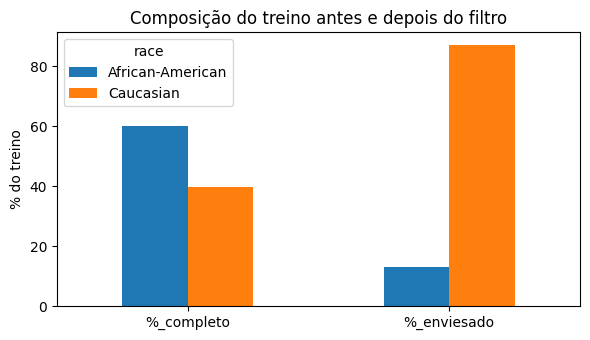

In [8]:
SEED = 42
train, test = split(df, SEED)
biased = make_biased_train(train, SEED)

comp = pd.DataFrame({"n_completo": train.race.value_counts(),
                     "n_enviesado": biased.race.value_counts()})
comp["%_completo"] = 100 * comp.n_completo / comp.n_completo.sum()
comp["%_enviesado"] = 100 * comp.n_enviesado / comp.n_enviesado.sum()
print(comp.round(1))
print(f"\nTaxa de reincidência no treino: completo = {train[TARGET].mean():.3f}, "
      f"enviesado = {biased[TARGET].mean():.3f}")

ax = comp[["%_completo", "%_enviesado"]].T.plot.bar(rot=0, figsize=(6, 3.5))
ax.set_ylabel("% do treino")
ax.set_title("Composição do treino antes e depois do filtro")
plt.tight_layout()
plt.show()

Perfil dos afro-americanos que ficam no treino em cada método (semente 42):

In [9]:
def kept_profile(sampling):
    b = make_biased_train(train, SEED, sampling=sampling)
    return b[b.race == GROUP_SUB][["priors_count", TARGET]].mean()


profile = {name: kept_profile(name) for name in SAMPLERS}
profile["grupo completo"] = train[train.race == GROUP_SUB][["priors_count", TARGET]].mean()
pd.DataFrame(profile).T.rename(columns={TARGET: "taxa_reincidencia"})

,priors_count,taxa_reincidencia
aleatorio,3.928,0.491
poucos_antecedentes,0.527,0.347
muitos_antecedentes,13.243,0.757
reincidentes_x3,5.266,0.766
reincidentes_x10,5.968,0.941
grupo completo,4.219,0.523


## 3. Exemplo do efeito

Dois modelos iguais (regressão logística, sem `race`): um treinado com o treino completo e outro com o treino filtrado por sorteio. Os dois são testados no mesmo teste.

Duas explicações possíveis:

- **H1:** o modelo aprende pior o grupo reduzido, e só ele piora.
- **H2:** reduzir o grupo muda a taxa de reincidência do treino, o modelo ajusta o risco médio e o corte de 0,5, e os dois grupos mudam juntos.

In [10]:
cols = features(False)
base = build_model("logistic", False).fit(train[cols], train[TARGET])
bias = build_model("logistic", False).fit(biased[cols], biased[TARGET])

y_test, race_test = test[TARGET].to_numpy(), test.race.to_numpy()
pd.concat({
    "baseline": metrics_by_group(y_test, base.predict(test[cols]), race_test),
    "enviesado": metrics_by_group(y_test, bias.predict(test[cols]), race_test),
}, names=["modelo"])[["n", "taxa_base", "TPR", "FNR", "FPR", "precisao", "acuracia"]]

n  taxa_base    TPR    FNR    FPR  precisao  acuracia
modelo    grupo                                                                       
baseline  African-American   953.0      0.524  0.673  0.327  0.324     0.696     0.675
          Caucasian          631.0      0.391  0.445  0.555  0.161     0.640     0.685
          Geral             1584.0      0.471  0.598  0.402  0.249     0.681     0.679
enviesado African-American   953.0      0.524  0.629  0.371  0.278     0.714     0.674
          Caucasian          631.0      0.391  0.409  0.591  0.138     0.656     0.685
          Geral             1584.0      0.471  0.556  0.444  0.214     0.699     0.678

Probabilidade média prevista por grupo. A queda ocorre só no grupo reduzido (H1) ou nos dois (H2)? Mudanças pequenas aqui já alteram bastante o TPR e o FPR, porque muitos casos ficam perto do corte de 0,5. Este exemplo usa uma só semente, e a seção 4 repete tudo com várias.

In [11]:
p_base = pd.Series(base.predict_proba(test[cols])[:, 1], index=test.index)
p_bias = pd.Series(bias.predict_proba(test[cols])[:, 1], index=test.index)
pd.DataFrame({
    "taxa real": test.groupby("race")[TARGET].mean(),
    "prob. média, baseline": p_base.groupby(test.race).mean(),
    "prob. média, enviesado": p_bias.groupby(test.race).mean(),
})

,taxa real,"prob. média, baseline","prob. média, enviesado"
race,,,
African-American,0.524,0.522,0.511
Caucasian,0.391,0.399,0.392


## 4. Todos os casos

Cada caso treina um **baseline** (treino completo) e um modelo **enviesado** (treino filtrado), testa os dois no mesmo teste e repete com `N_SEEDS` sementes. Os casos variam o modelo, o uso de `race`, o grupo reduzido e o método de amostragem. Nas tabelas, o grupo reduzido aparece como `reduzido` e o outro como `outro`.

In [12]:
CASES = {
    "A1 sorteio | logística": dict(),
    "A2 sorteio | logística, reduz caucasianos": dict(sub=GROUP_REF),
    "A3 sorteio | floresta": dict(model="forest"),
    "A4 sorteio | logística + race": dict(use_race=True),
    "A5 sorteio | floresta + race": dict(model="forest", use_race=True),
    "B1 poucos antecedentes | logística": dict(sampling="poucos_antecedentes"),
    "B2 poucos antecedentes | floresta + race": dict(sampling="poucos_antecedentes", model="forest", use_race=True),
    "C1 muitos antecedentes | logística": dict(sampling="muitos_antecedentes"),
    "C2 muitos antecedentes | floresta + race": dict(sampling="muitos_antecedentes", model="forest", use_race=True),
    "D1 reincidentes x3 | logística": dict(sampling="reincidentes_x3"),
    "D2 reincidentes x10 | logística": dict(sampling="reincidentes_x10"),
    "D3 reincidentes x3 | floresta + race": dict(sampling="reincidentes_x3", model="forest", use_race=True),
    "D4 reincidentes x10 | floresta + race": dict(sampling="reincidentes_x10", model="forest", use_race=True),
}


def run_case(case, seed, model="logistic", use_race=False, sampling="aleatorio", sub=GROUP_SUB):
    cols = features(use_race)
    train, test = split(df, seed)
    biased = make_biased_train(train, seed, sub, sampling)
    y, race = test[TARGET].to_numpy(), test.race.to_numpy()

    rows = []
    for label, data in [("baseline", train), ("enviesado", biased)]:
        fitted = build_model(model, use_race).fit(data[cols], data[TARGET])
        out = metrics_by_group(y, fitted.predict(test[cols]), race).reset_index()
        out["papel"] = np.where(out.grupo == sub, "reduzido", np.where(out.grupo == "Geral", "geral", "outro"))
        out["caso"], out["modelo"], out["seed"] = case, label, seed
        rows.append(out)
    return pd.concat(rows, ignore_index=True)


res = pd.concat(
    [run_case(case, seed, **spec) for case, spec in CASES.items() for seed in range(N_SEEDS)],
    ignore_index=True,
)

Taxas médias por grupo, antes e depois do filtro:

In [13]:
by_group = res[res.papel != "geral"].pivot_table(
    index=["caso", "papel"], columns="modelo", values=["FNR", "FPR"]
)
by_group = by_group.reindex(pd.MultiIndex.from_product([list(CASES), ["reduzido", "outro"]]))
by_group[[("FNR", "baseline"), ("FNR", "enviesado"), ("FPR", "baseline"), ("FPR", "enviesado")]].round(3)

FNR                FPR          
modelo                                             baseline enviesado baseline enviesado
A1 sorteio | logística                    reduzido    0.323     0.408    0.312     0.244
                                          outro       0.585     0.647    0.154     0.119
A2 sorteio | logística, reduz caucasianos reduzido    0.585     0.568    0.154     0.185
                                          outro       0.323     0.297    0.312     0.352
A3 sorteio | floresta                     reduzido    0.327     0.412    0.313     0.252
                                          outro       0.568     0.638    0.160     0.121
A4 sorteio | logística + race             reduzido    0.304     0.381    0.330     0.273
                                          outro       0.616     0.653    0.130     0.116
A5 sorteio | floresta + race              reduzido    0.311     0.367    0.324     0.293
                                          outro       0.622     0.658    0.127     0.108
B1 poucos antecedentes | logística        reduzido    0.323     0.415    0.312     0.241
                                          outro       0.585     0.646    0.154     0.116
B2 poucos antecedentes | floresta + race  reduzido    0.311     0.503    0.324     0.191
                                          outro       0.622     0.661    0.127     0.108
C1 muitos antecedentes | logística        reduzido    0.323     0.412    0.312     0.238
                                          outro       0.585     0.667    0.154     0.112
C2 muitos antecedentes | floresta + race  reduzido    0.311     0.149    0.324     0.592
                                          outro       0.622     0.665    0.127     0.107
D1 reincidentes x3 | logística            reduzido    0.323     0.297    0.312     0.342
                                          outro       0.585     0.551    0.154     0.174
D2 reincidentes x10 | logística           reduzido    0.323     0.246    0.312     0.399
                                          outro       0.585     0.496    0.154     0.215
D3 reincidentes x3 | floresta + race      reduzido    0.311     0.032    0.324     0.885
                                          outro       0.622     0.642    0.127     0.118
D4 reincidentes x10 | floresta + race     reduzido    0.311     0.000    0.324     0.999
                                          outro       0.622     0.633    0.127     0.125

Variação (enviesado menos baseline): média das sementes, com o desvio-padrão entre parênteses. A coluna `diferença` é a variação do grupo reduzido menos a do outro grupo. Uma variação pequena perto do desvio pode ser acaso.

In [14]:
wide = res[res.papel != "geral"].pivot_table(
    index=["caso", "seed", "papel"], columns="modelo", values=["FNR", "FPR"]
)
delta = (wide.xs("enviesado", axis=1, level=1) - wide.xs("baseline", axis=1, level=1)).unstack("papel")
for m in ["FNR", "FPR"]:
    delta[(m, "diferença")] = delta[(m, "reduzido")] - delta[(m, "outro")]

order = [(m, p) for m in ["FNR", "FPR"] for p in ["reduzido", "outro", "diferença"]]
mean = delta.groupby("caso").mean()[order].reindex(list(CASES))
std = delta.groupby("caso").std()[order].reindex(list(CASES))
mean.map("{:+.3f}".format) + " (" + std.map("{:.3f}".format) + ")"

FNR                                             FPR                                
papel                                            reduzido           outro       diferença        reduzido           outro       diferença
caso                                                                                                                                     
A1 sorteio | logística                     +0.086 (0.027)  +0.062 (0.030)  +0.024 (0.019)  -0.068 (0.026)  -0.035 (0.019)  -0.033 (0.021)
A2 sorteio | logística, reduz caucasianos  -0.017 (0.016)  -0.025 (0.011)  +0.008 (0.017)  +0.031 (0.011)  +0.040 (0.014)  -0.009 (0.013)
A3 sorteio | floresta                      +0.085 (0.022)  +0.070 (0.025)  +0.015 (0.023)  -0.061 (0.021)  -0.038 (0.017)  -0.023 (0.020)
A4 sorteio | logística + race              +0.077 (0.093)  +0.038 (0.022)  +0.039 (0.096)  -0.057 (0.073)  -0.014 (0.010)  -0.043 (0.072)
A5 sorteio | floresta + race               +0.056 (0.060)  +0.036 (0.020)  +0.020 (0.053)  -0.031 (0.044)  -0.019 (0.015)  -0.012 (0.038)
B1 poucos antecedentes | logística         +0.092 (0.028)  +0.061 (0.027)  +0.031 (0.023)  -0.070 (0.028)  -0.038 (0.018)  -0.032 (0.020)
B2 poucos antecedentes | floresta + race   +0.192 (0.057)  +0.039 (0.018)  +0.153 (0.059)  -0.132 (0.039)  -0.019 (0.012)  -0.113 (0.039)
C1 muitos antecedentes | logística         +0.090 (0.029)  +0.082 (0.030)  +0.008 (0.021)  -0.074 (0.023)  -0.042 (0.017)  -0.032 (0.020)
C2 muitos antecedentes | floresta + race   -0.162 (0.060)  +0.042 (0.022)  -0.205 (0.063)  +0.268 (0.114)  -0.020 (0.016)  +0.289 (0.116)
D1 reincidentes x3 | logística             -0.025 (0.022)  -0.034 (0.021)  +0.009 (0.019)  +0.030 (0.027)  +0.020 (0.016)  +0.009 (0.020)
D2 reincidentes x10 | logística            -0.077 (0.016)  -0.089 (0.023)  +0.013 (0.023)  +0.088 (0.024)  +0.061 (0.021)  +0.026 (0.015)
D3 reincidentes x3 | floresta + race       -0.280 (0.024)  +0.020 (0.015)  -0.299 (0.028)  +0.561 (0.053)  -0.010 (0.014)  +0.571 (0.058)
D4 reincidentes x10 | floresta + race      -0.311 (0.026)  +0.011 (0.015)  -0.322 (0.031)  +0.675 (0.027)  -0.003 (0.011)  +0.678 (0.031)

Os mesmos resultados em gráficos, uma família por bloco e um caso por linha. À esquerda fica o **FNR** (reincidentes que passaram batido) e à direita o **FPR** (não reincidentes marcados como alto risco). Em cada gráfico, a primeira barra de cada cor é o baseline e a segunda é o enviesado. A barra listrada é o grupo reduzido a 10%, por isso só existe no enviesado.

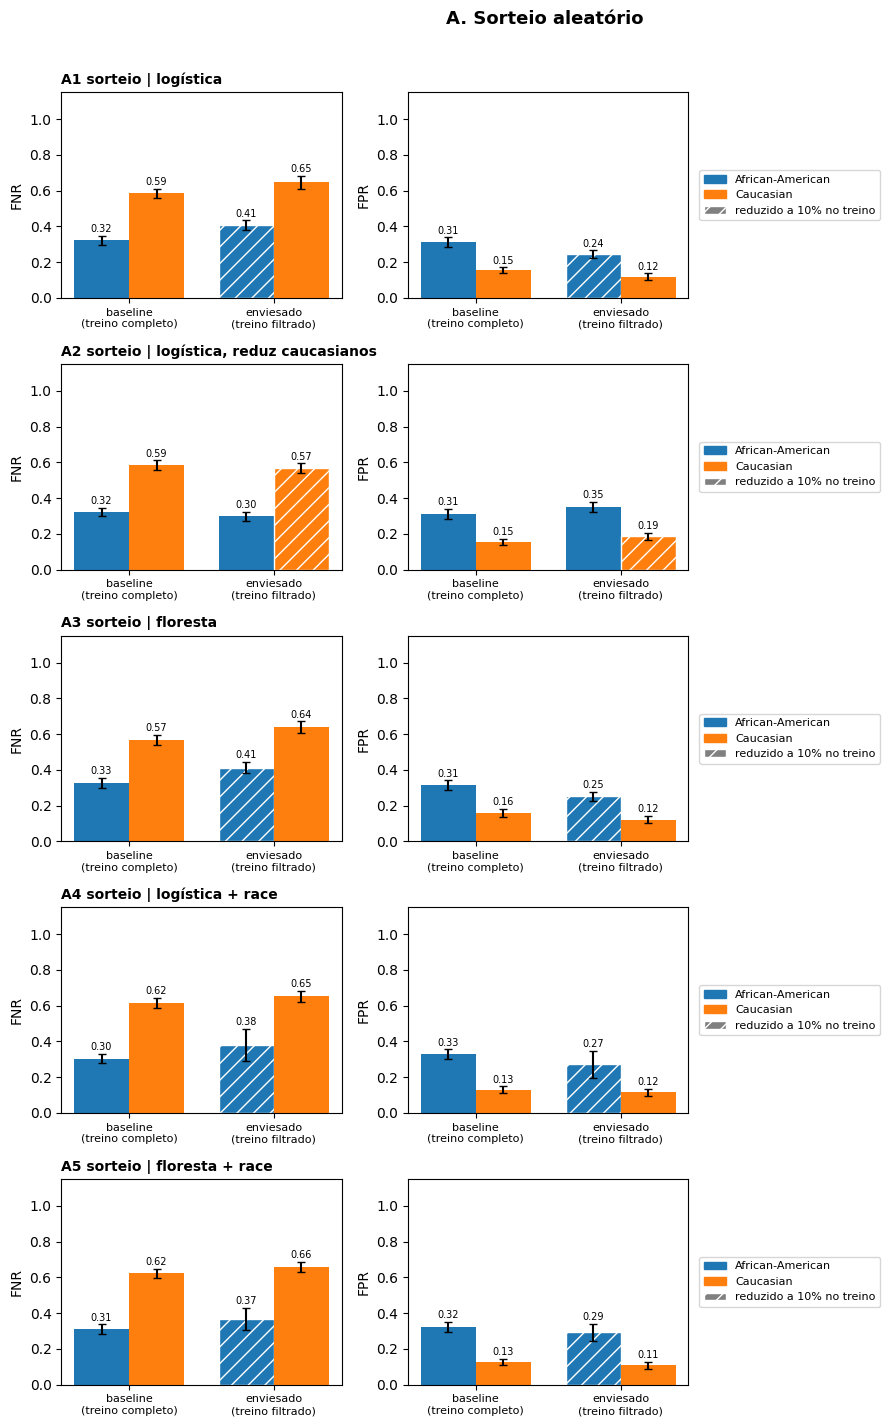

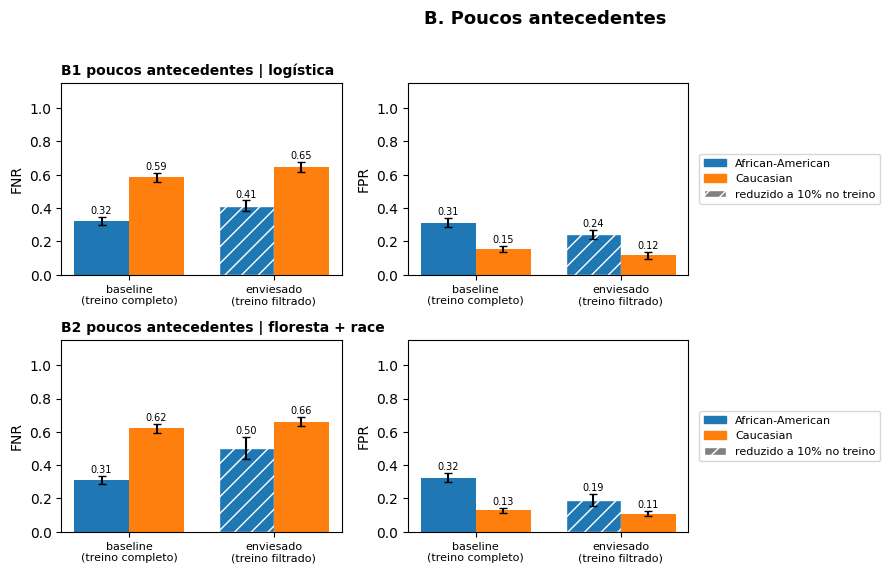

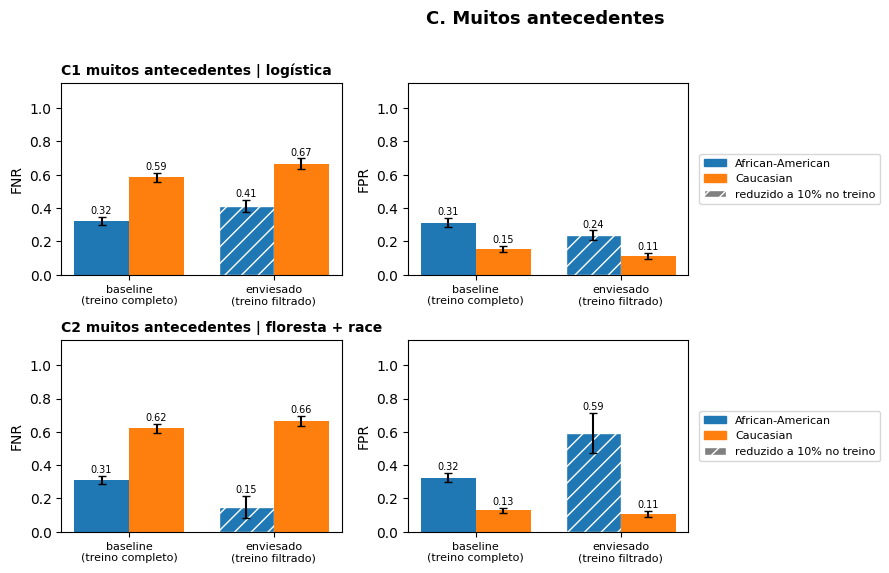

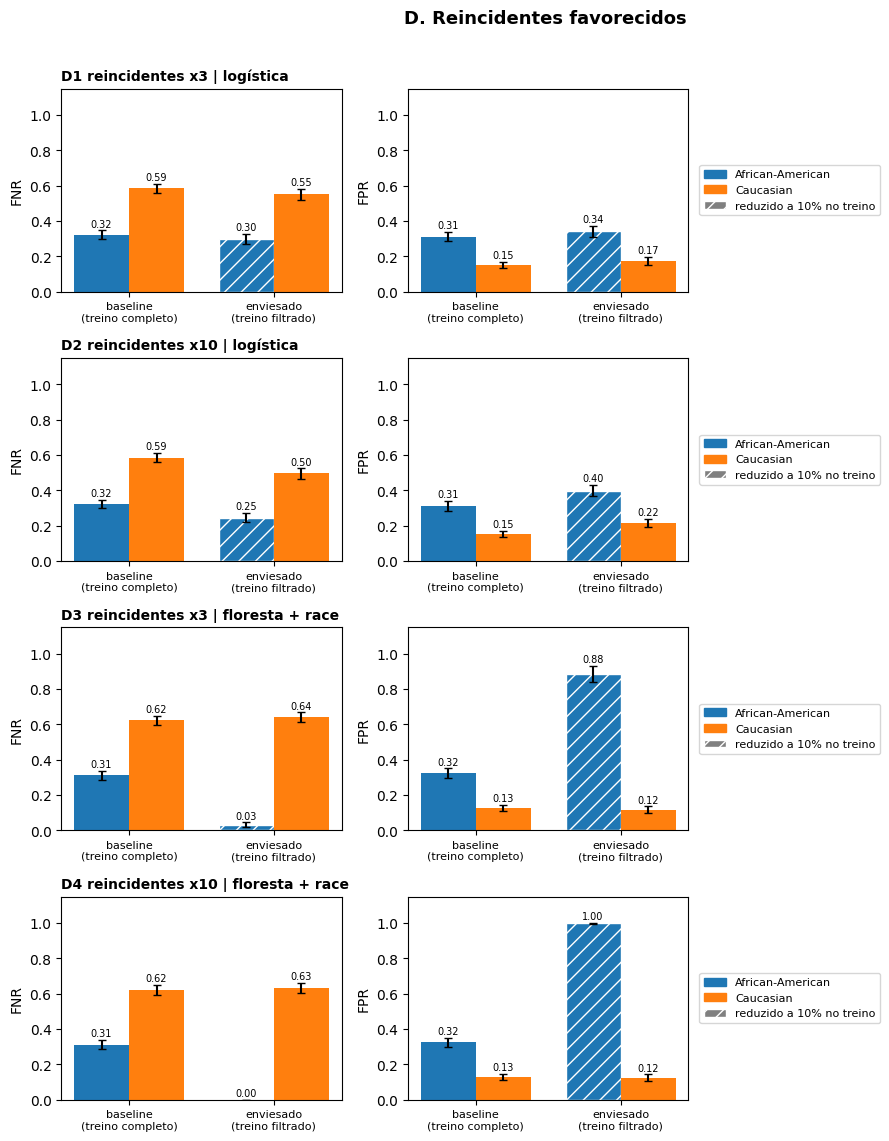

In [15]:
FAMILIES = {"A": "A. Sorteio aleatório", "B": "B. Poucos antecedentes",
            "C": "C. Muitos antecedentes", "D": "D. Reincidentes favorecidos"}
COLORS = {GROUP_SUB: "tab:blue", GROUP_REF: "tab:orange"}
MODELS = ["baseline", "enviesado"]

stats = res[res.papel != "geral"].groupby(["caso", "grupo", "modelo"])[["FNR", "FPR"]].agg(["mean", "std"])
legend_items = [Patch(color=COLORS[g], label=g) for g in GROUPS]
legend_items.append(Patch(facecolor="gray", edgecolor="white", hatch="//", label="reduzido a 10% no treino"))


def plot_family(letter):
    cases = [c for c in CASES if c[0] == letter]
    fig, axes = plt.subplots(len(cases), 2, figsize=(11, 2.9 * len(cases)), squeeze=False)
    for row, case in zip(axes, cases):
        reduced = CASES[case].get("sub", GROUP_SUB)
        for ax, metric in zip(row, ["FNR", "FPR"]):
            for k, group in enumerate(GROUPS):
                for j, model in enumerate(MODELS):
                    v = stats.loc[(case, group, model), (metric, "mean")]
                    e = stats.loc[(case, group, model), (metric, "std")]
                    x = j + (k - 0.5) * 0.38
                    striped = model == "enviesado" and group == reduced
                    ax.bar(x, v, 0.38, yerr=e, capsize=3, color=COLORS[group],
                           hatch="//" if striped else None, edgecolor="white" if striped else None)
                    ax.text(x, v + e + 0.02, f"{v:.2f}", ha="center", fontsize=7)
            ax.set_xticks([0, 1])
            ax.set_xticklabels(["baseline\n(treino completo)", "enviesado\n(treino filtrado)"], fontsize=8)
            ax.set_ylim(0, 1.15)
            ax.set_ylabel(metric)
        row[0].set_title(case, loc="left", fontweight="bold", fontsize=10)
        row[1].legend(handles=legend_items, loc="center left", bbox_to_anchor=(1.02, 0.5), fontsize=8)
    fig.suptitle(FAMILIES[letter], fontsize=13, fontweight="bold")
    fig.tight_layout(rect=(0, 0, 0.82, 0.97))
    plt.show()


for letter in FAMILIES:
    plot_family(letter)

Disparidade antes e depois do filtro, sempre como taxa dos afro-americanos menos taxa dos caucasianos (inclusive no A2). O ponto cinza é o baseline, a disparidade que já existe sem filtro. O ponto vermelho é o enviesado, e a seta mostra a mudança. Seta curta quer dizer que o filtro quase não alterou a disparidade. As barras vermelhas são o desvio entre sementes.

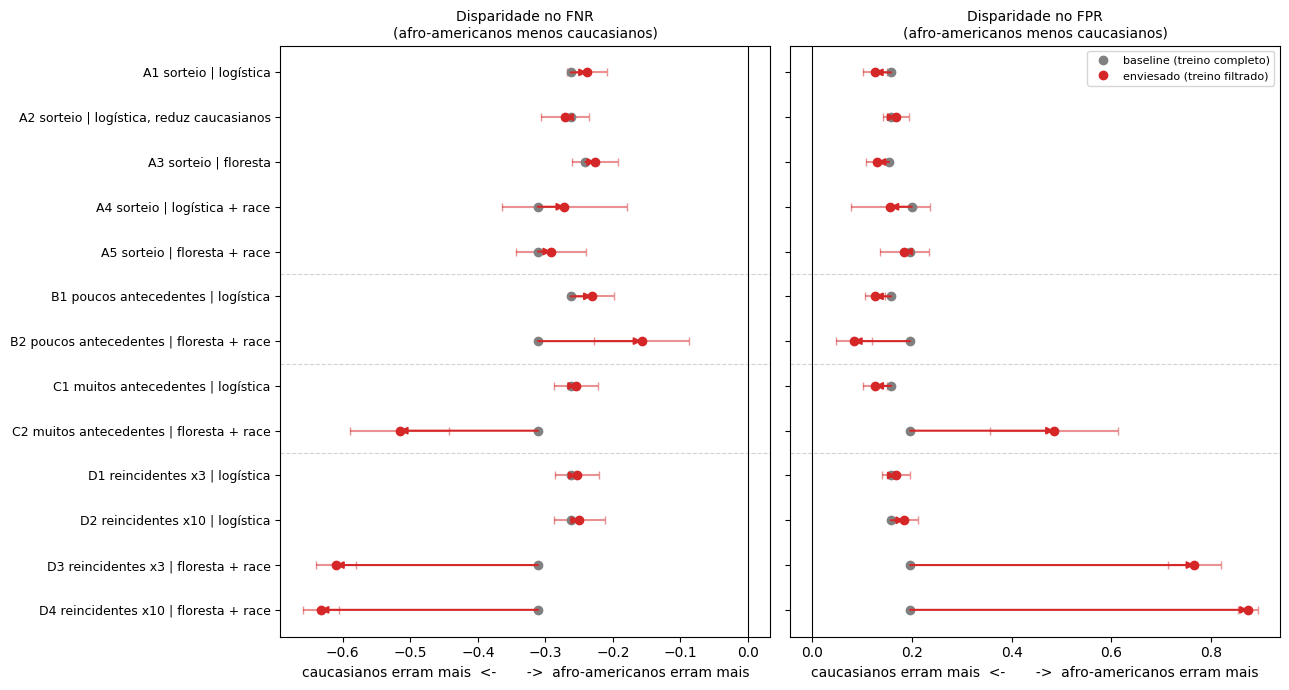

In [16]:
wide = res[res.papel != "geral"].pivot_table(
    index=["caso", "seed", "modelo"], columns="grupo", values=["FNR", "FPR"]
)
gap = wide.xs(GROUP_SUB, axis=1, level=1) - wide.xs(GROUP_REF, axis=1, level=1)
gap_mean = gap.groupby(["caso", "modelo"]).mean()
gap_std = gap.groupby(["caso", "modelo"]).std()

fig, axes = plt.subplots(1, 2, figsize=(13, 7), sharey=True)
case_names = list(CASES)
for ax, metric in zip(axes, ["FNR", "FPR"]):
    for i, case in enumerate(case_names):
        start = gap_mean.loc[(case, "baseline"), metric]
        end = gap_mean.loc[(case, "enviesado"), metric]
        err = gap_std.loc[(case, "enviesado"), metric]
        ax.annotate("", xy=(end, i), xytext=(start, i),
                    arrowprops=dict(arrowstyle="-|>", color="tab:red", lw=1.5, shrinkA=0, shrinkB=0))
        ax.errorbar(end, i, xerr=err, fmt="none", ecolor="tab:red", capsize=3, alpha=0.5)
        ax.plot(start, i, "o", color="gray")
        ax.plot(end, i, "o", color="tab:red")
        if i and case[0] != case_names[i - 1][0]:
            ax.axhline(i - 0.5, color="lightgray", linestyle="--", linewidth=0.8)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_title(f"Disparidade no {metric}\n(afro-americanos menos caucasianos)", fontsize=10)
    ax.set_xlabel("caucasianos erram mais  <-       ->  afro-americanos erram mais")

axes[0].set_yticks(range(len(case_names)))
axes[0].set_yticklabels(case_names, fontsize=9)
axes[0].invert_yaxis()
axes[1].legend(
    handles=[
        Line2D([], [], marker="o", color="gray", linestyle="", label="baseline (treino completo)"),
        Line2D([], [], marker="o", color="tab:red", linestyle="", label="enviesado (treino filtrado)"),
    ],
    loc="upper right", fontsize=8,
)
plt.tight_layout()
plt.show()